In [100]:
import warnings
import sys
from pathlib import Path

import pandas as pd
import plotnine as p9
import matplotlib as mpl
import numpy as np
import yfinance as yf
sys.path.insert(0, str(Path("..").resolve()))
from src.data import load_fx_spot, prepare_bbg_data
from src.plotting import build_all_fx_spot_plots, plot_rebased_equity_indices, plot_cds_data
from sklearn.linear_model import Lasso, LassoCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

warnings.filterwarnings("ignore")
p9.theme_set(p9.theme_gray())
mpl.rcParams["figure.edgecolor"] = "none"
mpl.rcParams["savefig.transparent"] = True

START_DATE = "2021-01-01"
END_DATE = "2026-02-20"
DATA_DIR = Path("../data")

eqy = pd.read_excel(DATA_DIR / "equity_indices.xlsx", parse_dates=["Dates"])
eqy = prepare_bbg_data(eqy, START_DATE, END_DATE)

display(eqy.head())

spx = yf.download("^GSPC", start=START_DATE, end=END_DATE)
ftse = yf.download("^FTSE", start=START_DATE, end=END_DATE)

eqy['SPX Index'] = spx['Close']
eqy['FTSE Index'] = ftse['Close']

eqy


# Mexico, Brazil, South Africa, Japan, Australia, Canada

,MEXBOL Index,IBOV Index,JALSH Index,NKY Index,AS51 Index,SPTSX Index
date,,,,,,
2021-01-04,44703.00,118854.71,60479.42,27258.38,6684.247,17527.77
2021-01-05,44908.12,119376.21,60921.37,27158.63,6681.858,17682.51
2021-01-06,45587.16,119100.08,61857.42,27055.94,6607.054,17828.11
2021-01-07,46188.66,122385.92,63042.88,27490.13,6711.953,18027.57
2021-01-08,46729.30,125076.63,63519.18,28139.03,6757.869,18042.07


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,MEXBOL Index,IBOV Index,JALSH Index,NKY Index,AS51 Index,SPTSX Index,SPX Index,FTSE Index
date,,,,,,,,
2021-01-04,44703.00,118854.71,60479.42,27258.38,6684.247,17527.77,3700.649902,6571.899902
2021-01-05,44908.12,119376.21,60921.37,27158.63,6681.858,17682.51,3726.860107,6612.299805
2021-01-06,45587.16,119100.08,61857.42,27055.94,6607.054,17828.11,3748.139893,6841.899902
2021-01-07,46188.66,122385.92,63042.88,27490.13,6711.953,18027.57,3803.790039,6857.000000
2021-01-08,46729.30,125076.63,63519.18,28139.03,6757.869,18042.07,3824.679932,6873.299805
...,...,...,...,...,...,...,...,...
2026-02-13,71478.81,186464.30,120584.10,56941.97,8917.612,33073.71,6836.169922,10446.400391
2026-02-16,71353.29,186464.30,120988.60,56806.41,8937.095,33073.71,NaN,10473.700195
2026-02-17,71155.69,186464.30,119410.00,56566.49,8958.878,32896.55,6843.220215,10556.200195


In [101]:
eqy_returns = eqy.pct_change().fillna(method='ffill')
eqy_returns

,MEXBOL Index,IBOV Index,JALSH Index,NKY Index,AS51 Index,SPTSX Index,SPX Index,FTSE Index
date,,,,,,,,
2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,0.004589,0.004388,0.007307,-0.003659,-0.000357,0.008828,0.007083,0.006147
2021-01-06,0.015121,-0.002313,0.015365,-0.003781,-0.011195,0.008234,0.005710,0.034723
2021-01-07,0.013195,0.027589,0.019164,0.016048,0.015877,0.011188,0.014847,0.002207
2021-01-08,0.011705,0.021985,0.007555,0.023605,0.006841,0.000804,0.005492,0.002377
...,...,...,...,...,...,...,...,...
2026-02-13,0.008334,-0.006935,-0.013332,-0.012107,-0.013925,0.018741,0.000499,0.004230
2026-02-16,-0.001756,0.000000,0.003355,-0.002381,0.002185,0.000000,0.000000,0.002613
2026-02-17,-0.002769,0.000000,-0.013048,-0.004223,0.002437,-0.005357,0.001031,0.007877


In [102]:
mex = eqy_returns[['MEXBOL Index', 'SPX Index']]
bra = eqy_returns[['IBOV Index', 'SPX Index']]
saf = eqy_returns[['JALSH Index', 'SPX Index']]
jpn = eqy_returns[['NKY Index', 'SPX Index']]
aus = eqy_returns[['AS51 Index', 'SPX Index']]
can = eqy_returns[['SPTSX Index', 'SPX Index']]
gb = eqy_returns[['FTSE Index', 'SPX Index']]

countries = {
    'Mexico': mex,
    'Brazil': bra,
    'South Africa': saf,
    'Japan': jpn,
    'Australia': aus,
    'Canada': can,
    'UK': gb
}

In [103]:
for country, data in countries.items():
    data['Excess Return'] = data.iloc[:, 0] - data['SPX Index']
    data['rolling 20 day volatility'] = data['Excess Return'].rolling(window=20).std()
    data['rolling 10 day volatility'] = data['Excess Return'].rolling(window=10).std()
    data['rolling 5 day volatility'] = data['Excess Return'].rolling(window=5).std()
    data['rolling 20 day mean'] = data['Excess Return'].rolling(window=20).mean()
    data['rolling 10 day mean'] = data['Excess Return'].rolling(window=10).mean()
    data['rolling 5 day mean'] = data['Excess Return'].rolling(window=5).mean()
    data['rolling 3 day mean'] = data['Excess Return'].rolling(window=3).mean()
    print(f"{country} - Excess Return and Rolling Statistics:")
    display(data.tail())

Mexico - Excess Return and Rolling Statistics:


,MEXBOL Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2026-02-13,0.008334,0.000499,0.007835,0.013132,0.013428,0.002888,0.003931,0.007141,0.004676,0.006070
2026-02-16,-0.001756,0.000000,-0.001756,0.013191,0.013096,0.004025,0.003600,0.007505,0.003286,0.003926
2026-02-17,-0.002769,0.001031,-0.003801,0.012383,0.006859,0.005031,0.002219,0.003124,0.002531,0.000759
2026-02-18,-0.003801,0.005566,-0.009367,0.012510,0.006866,0.007049,0.002069,0.003121,-0.000278,-0.004975
2026-02-19,-0.000558,-0.002822,0.002264,0.012490,0.005679,0.006464,0.002227,0.001936,-0.000965,-0.003635


Brazil - Excess Return and Rolling Statistics:


,IBOV Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2026-02-13,-0.006935,0.000499,-0.007434,0.013515,0.014104,0.010679,0.006998,0.004304,0.006658,0.006121
2026-02-16,0.000000,0.000000,0.000000,0.013523,0.014162,0.010259,0.006983,0.004055,0.003999,-0.000654
2026-02-17,0.000000,0.001031,-0.001031,0.012556,0.012306,0.010479,0.005468,0.001535,0.003466,-0.002822
2026-02-18,-0.002403,0.005566,-0.007969,0.012285,0.011199,0.005607,0.003983,0.002367,-0.002192,-0.003000
2026-02-19,0.013537,-0.002822,0.016359,0.012279,0.011429,0.009842,0.003977,0.002547,-0.000015,0.002453


South Africa - Excess Return and Rolling Statistics:


...

,AS51 Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2026-02-13,-0.013925,0.000499,-0.014424,0.014343,0.019367,0.013729,0.000835,0.002066,0.007585,0.007034
2026-02-16,0.002185,0.000000,0.002185,0.014313,0.018354,0.013389,0.001109,0.003845,0.005256,0.002204
2026-02-17,0.002437,0.001031,0.001406,0.013988,0.017733,0.013475,0.000478,0.002252,0.004939,-0.003611
2026-02-18,0.005370,0.005566,-0.000196,0.013488,0.017326,0.011811,0.001235,0.000925,0.001564,0.001131
2026-02-19,0.008791,-0.002822,0.011613,0.013687,0.017530,0.009349,0.001715,0.001294,0.000117,0.004274


Canada - Excess Return and Rolling Statistics:


,SPTSX Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2026-02-13,0.018741,0.000499,0.018242,0.010615,0.009383,0.010505,0.000845,0.005082,0.006569,0.003383
2026-02-16,0.000000,0.000000,0.000000,0.010615,0.009499,0.010261,0.000769,0.004806,0.004105,0.003393
2026-02-17,-0.005357,0.001031,-0.006388,0.010480,0.009389,0.010437,-0.000067,0.002691,0.000752,0.003951
2026-02-18,0.014992,0.005566,0.009426,0.010488,0.009275,0.011096,0.000829,0.002561,0.002643,0.001013
2026-02-19,0.006147,-0.002822,0.008969,0.010633,0.009006,0.009485,0.001322,0.004004,0.006050,0.004002


UK - Excess Return and Rolling Statistics:


,FTSE Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2026-02-13,0.004230,0.000499,0.003731,0.007666,0.007904,0.006037,0.001752,0.003630,0.004257,0.008070
2026-02-16,0.002613,0.000000,0.002613,0.007551,0.007857,0.004681,0.002077,0.003275,0.005402,0.005116
2026-02-17,0.007877,0.001031,0.006846,0.007123,0.007902,0.003662,0.001725,0.003380,0.006734,0.004397
2026-02-18,0.012315,0.005566,0.006749,0.006592,0.007185,0.002584,0.002586,0.002698,0.005789,0.005403
2026-02-19,-0.005540,-0.002822,-0.002718,0.006513,0.007379,0.003913,0.002665,0.002096,0.003444,0.003626


In [104]:
residuals = pd.read_csv(DATA_DIR / "stage1_residuals.csv").set_index('date')
country_residuals = {}
country_residuals['Australia'] = residuals['AUD']
country_residuals['Canada'] = residuals['CAD']
country_residuals['Japan'] = residuals['JPY']
country_residuals['Mexico'] = residuals['MXN']
country_residuals['South Africa'] = residuals['ZAR']
country_residuals['UK'] = residuals['GBP']


In [ ]:

def evaluate_signal(predictions, y_test, top_pcts=[0.2]):
    predictions = pd.Series(predictions, index=y_test.index)
    y_test = pd.Series(y_test)
    directional_accuracy = np.mean(
        np.sign(predictions) == np.sign(y_test)
    )
    print("Overall Directional Accuracy:", directional_accuracy)
    strong_accuracies = []
    for top_pct in top_pcts:
        threshold = predictions.abs().quantile(1 - top_pct)
        # print(f"Threshold for top {int(top_pct*100)}% signals: {threshold:.4f}")
        strong_mask = predictions.abs() >= threshold
        strong_directional_accuracy = np.mean(
            np.sign(predictions[strong_mask]) == np.sign(y_test[strong_mask])
        )
        print(f"Top {int(top_pct*100)}% Strongest Signals:")
        print("Directional Accuracy:", strong_directional_accuracy)
        strong_accuracies.append((top_pct, strong_directional_accuracy))
    return {
        "overall_direction": directional_accuracy,
        "strong_direction": strong_directional_accuracy
    }, strong_accuracies


def ols_regression(X_train, y_train, X_test, y_test):
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    display(pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': lr.coef_
    }))
    train_predictions = lr.predict(X_train)
    _, strong_accuracies_train = evaluate_signal(train_predictions, y_train)
    train_r2 = lr.score(X_train, y_train)
    predictions = lr.predict(X_test)
    df = pd.DataFrame({
        'Actual': y_test,
        'Predicted': predictions
    })
    display(df)
    print(f"R^2 Score: {lr.score(X_test, y_test)}")
    _, strong_accuracies_test = evaluate_signal(predictions, y_test)
    return predictions, lr, df[['Actual']], train_r2, lr.score(X_test, y_test), strong_accuracies_train, strong_accuracies_test



def standard_lasso_cv(X_train, y_train, X_test, y_test, alphas=None):
    
    if alphas is None:
        alphas = np.logspace(-5, 1, 100)
    # print(alphas)
    tscv = TimeSeriesSplit(n_splits=5)
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", LassoCV(
            alphas=alphas,
            cv=tscv,
            fit_intercept=True,
            max_iter=10000
        ))
    ])
    model.fit(X_train, y_train)
    lasso = model.named_steps["lasso"]
    print(f"Chosen alpha: {lasso.alpha_}")
    display(pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': lasso.coef_
    }))
    train_predictions = model.predict(X_train)
    train_r2 = model.score(X_train, y_train)
    _, strong_accuracies_train = evaluate_signal(train_predictions, y_train)
    predictions = model.predict(X_test)
    display(pd.DataFrame({
        'Actual': y_test,
        'Predicted': predictions
    }))
    print(f"R^2 Score: {model.score(X_test, y_test)}")
    _, strong_accuracies_test = evaluate_signal(predictions, y_test)
    return predictions, model, y_test, train_r2, model.score(X_test, y_test), strong_accuracies_train, strong_accuracies_test

In [176]:


def random_forest_model(X_train, y_train, X_test, y_test):

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=4,      # keep shallow to prevent overfit
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)
    # print("Train R²:", rf.score(X_train, y_train))
    # train_predictions = rf.predict(X_train)
    # evaluate_signal(train_predictions, y_train)
    #print("Test R²:", rf.score(X_test, y_test))
    #predictions = rf.predict(X_test)
    # evaluate_signal(predictions, y_test)
    print("\nImportance-Based Feature Selection:")
    importances = pd.Series(
        rf.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)
    # print("\nFeature Importances:")
    # display(importances)
    top_features = importances.index[:int(len(importances)/2)]

    X_train_reduced = X_train[top_features]
    X_test_reduced  = X_test[top_features]

    rf_reduced = RandomForestRegressor(
        n_estimators=300,
        max_depth=3,
        min_samples_leaf=15,
        random_state=42,
        n_jobs=-1
    )

    rf_reduced.fit(X_train_reduced, y_train)
    train_predictions = rf_reduced.predict(X_train_reduced)
    train_r2 = rf_reduced.score(X_train_reduced, y_train)
    print("Training Data:")
    print("Train R² (Reduced):", train_r2)
    dic, strong_accuracies_train = evaluate_signal(train_predictions, y_train)
    print()
    print("Testing Data:")
    predictions_reduced = rf_reduced.predict(X_test_reduced)
    test_r2 = rf_reduced.score(X_test_reduced, y_test)
    print("Reduced Test R²:", test_r2)
    dic, strong_accuracies_test = evaluate_signal(predictions_reduced, y_test)
    #evaluate_signal(predictions_reduced, y_test)
    return predictions_reduced, rf_reduced, y_test, train_r2, test_r2, strong_accuracies_train, strong_accuracies_test


def gradient_boost_model(X_train, y_train, X_test, y_test):

    gbr = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.7,
        random_state=42
    )

    gbr.fit(X_train, y_train)
    print("Train R²:", gbr.score(X_train, y_train))
    print("Test R²:", gbr.score(X_test, y_test))

    predictions = gbr.predict(X_test)
    evaluate_signal(predictions, y_test)
    return predictions, gbr

In [177]:
def expanding_oos_rf(X, y, split_date):

    X_train_full = X.loc[:split_date]
    y_train_full = y.loc[:split_date]

    X_test_full = X.loc[split_date:]
    y_test_full = y.loc[split_date:]

    predictions = []
    actuals = []
    dates = []

    for date in X_test_full.index:

        X_train = X.loc[:date].iloc[:-1]
        y_train = y.loc[:date].iloc[:-1]

        X_test = X.loc[[date]]
        y_actual = y.loc[date]

        rf = RandomForestRegressor(
            n_estimators=300,
            max_depth=3,
            min_samples_leaf=15,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_train, y_train)

        pred = rf.predict(X_test)[0]

        predictions.append(pred)
        actuals.append(y_actual)
        dates.append(date)

    return pd.Series(predictions, index=dates), pd.Series(actuals, index=dates)

# OLS:

In [189]:
preds = pd.DataFrame()
train_r2s = {}
test_r2s = {}
train_accuracies = {}
test_accuracies = {}

for country, data in countries.items():
    if country not in country_residuals:
        print(f"Residuals for {country} not found. Skipping regression.")
        continue
    X_train = countries[country]['2022-01-01':'2024-09-30']
    y_train = country_residuals[country]['2022-01-01':'2024-09-30'].shift(-1).dropna()  # Shift to align with next day's return
    X_train = X_train.copy()
    y_train = y_train.copy()
    X_train.index = pd.to_datetime(X_train.index)
    y_train.index = pd.to_datetime(y_train.index)
    df_train = pd.concat([X_train, y_train], axis=1).dropna()
    df_train.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features

    X_test = countries[country]['2025-01-01':'2026-01-01']
    y_test = country_residuals[country]['2025-01-01':'2026-01-01'].shift(-1).dropna()  # Shift to align with next day's return
    X_test = X_test.copy()
    y_test = y_test.copy()
    X_test.index = pd.to_datetime(X_test.index)
    y_test.index = pd.to_datetime(y_test.index)
    df_test = pd.concat([X_test, y_test], axis=1).dropna()
    df_test.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features

    model_preds, model, ys, trains_r2, test_r2, strong_acc_train, strong_acc_test = ols_regression(df_train[['Excess Return']], df_train.iloc[:, -1], df_test[['Excess Return']], df_test.iloc[:, -1])
    display(ys)

    if country == 'Mexico':
        preds.index = ys.index
    preds[country] = model_preds
    train_r2s[country] = trains_r2
    test_r2s[country] = test_r2
    train_accuracies[country] = strong_acc_train
    test_accuracies[country] = strong_acc_test


,Feature,Coefficient
0,Excess Return,0.064316


Overall Directional Accuracy: 0.5106382978723404
Top 20% Strongest Signals:
Directional Accuracy: 0.5606060606060606


,Actual,Predicted
date,,
2025-01-03,0.009626,-0.001847
2025-01-06,-0.000437,0.000356
2025-01-07,0.002993,0.001491
2025-01-08,-0.003733,-0.000672
2025-01-09,-0.004295,0.000233
...,...,...
2025-12-22,0.000376,0.000409
2025-12-23,-0.002029,0.000526
2025-12-24,-0.002433,-0.000179


R^2 Score: -0.042828184674924774
Overall Directional Accuracy: 0.5294117647058824
Top 20% Strongest Signals:
Directional Accuracy: 0.5625


,Actual
date,
2025-01-03,0.009626
2025-01-06,-0.000437
2025-01-07,0.002993
2025-01-08,-0.003733
2025-01-09,-0.004295
...,...
2025-12-22,0.000376
2025-12-23,-0.002029
2025-12-24,-0.002433


...

,Feature,Coefficient
0,Excess Return,-0.00086


Overall Directional Accuracy: 0.5243161094224924
Top 20% Strongest Signals:
Directional Accuracy: 0.49242424242424243


,Actual,Predicted
date,,
2025-01-03,0.000526,0.000020
2025-01-06,-0.000357,0.000007
2025-01-07,-0.005235,-0.000004
2025-01-08,-0.002189,0.000006
2025-01-09,-0.001178,-0.000002
...,...,...
2025-12-22,-0.000981,0.000013
2025-12-23,-0.000477,0.000007
2025-12-24,0.001153,0.000010


R^2 Score: -0.0007077203447503067
Overall Directional Accuracy: 0.5126050420168067
Top 20% Strongest Signals:
Directional Accuracy: 0.5833333333333334


,Actual
date,
2025-01-03,0.000526
2025-01-06,-0.000357
2025-01-07,-0.005235
2025-01-08,-0.002189
2025-01-09,-0.001178
...,...
2025-12-22,-0.000981
2025-12-23,-0.000477
2025-12-24,0.001153


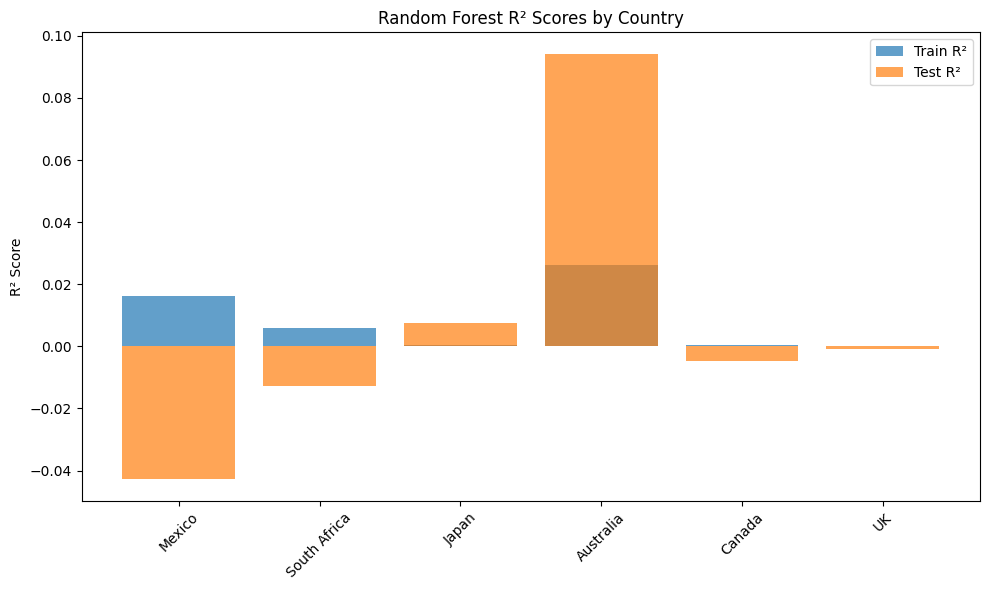

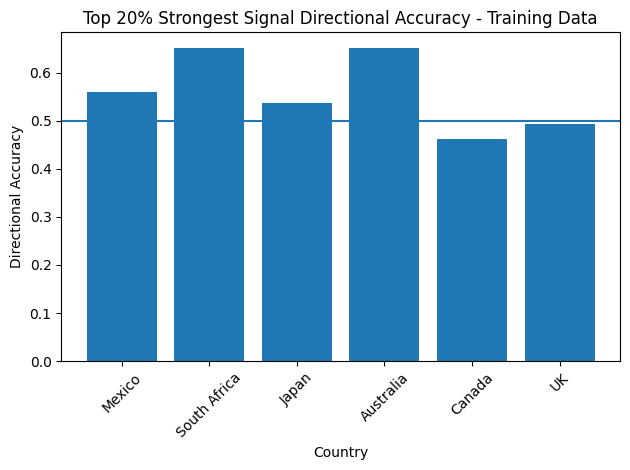

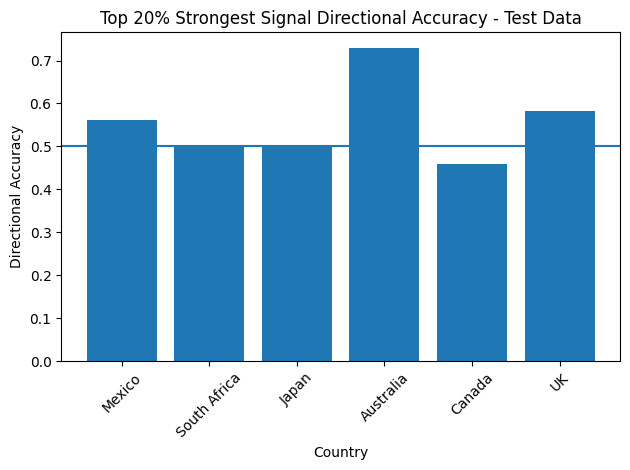

In [190]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(train_r2s.keys(), train_r2s.values(), alpha=0.7, label='Train R²')
plt.bar(test_r2s.keys(), test_r2s.values(), alpha=0.7, label='Test R²')
plt.ylabel('R² Score')
plt.title('Random Forest R² Scores by Country')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Extract countries and second value from tuple
countries2 = list(train_accuracies.keys())
values = [v[0][1] for v in train_accuracies.values()]

# Create bar plot
plt.figure()
plt.bar(countries2, values)

plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Training Data")
plt.xticks(rotation=45)

# Optional benchmark line at 0.5
plt.axhline(0.5)

plt.tight_layout()
plt.show()

# Extract countries and second value from tuple
countries2 = list(test_accuracies.keys())
values = [v[0][1] for v in test_accuracies.values()]

# Create bar plot
plt.figure()
plt.bar(countries2, values)

plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Test Data")
plt.xticks(rotation=45)

# Optional benchmark line at 0.5
plt.axhline(0.5)

plt.tight_layout()
plt.show()

# Lasso

In [191]:
preds = pd.DataFrame()
train_r2s = {}
test_r2s = {}
train_accuracies = {}
test_accuracies = {}

for country, data in countries.items():
    if country not in country_residuals:
        print(f"Residuals for {country} not found. Skipping regression.")
        continue
    X_train = countries[country]['2022-01-01':'2024-09-30']
    y_train = country_residuals[country]['2022-01-01':'2024-09-30'].shift(-1).dropna()  # Shift to align with next day's return
    X_train = X_train.copy()
    y_train = y_train.copy()
    X_train.index = pd.to_datetime(X_train.index)
    y_train.index = pd.to_datetime(y_train.index)
    df_train = pd.concat([X_train, y_train], axis=1).dropna()
    df_train.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features
    # print(f"{country} - Training Data for Lasso Regression:")
    # display(df_train)
    X_test = countries[country]['2025-01-01':'2026-01-01']
    y_test = country_residuals[country]['2025-01-01':'2026-01-01'].shift(-1).dropna()  # Shift to align with next day's return
    X_test = X_test.copy()
    y_test = y_test.copy()
    X_test.index = pd.to_datetime(X_test.index)
    y_test.index = pd.to_datetime(y_test.index)
    df_test = pd.concat([X_test, y_test], axis=1).dropna()
    df_test.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features

    print(f"\nLasso Regression Results for {country}:")
    
    Model_pred, model, ys, trains_r2, test_r2, strong_acc_train, strong_acc_test = standard_lasso_cv(df_train.iloc[:, :-1], df_train.iloc[:, -1], df_test.iloc[:, :-1], df_test.iloc[:, -1])

    if country == 'Mexico':
        preds.index = ys.index
    preds[country] = model_preds
    train_r2s[country] = trains_r2
    test_r2s[country] = test_r2
    train_accuracies[country] = strong_acc_train
    test_accuracies[country] = strong_acc_test

    


Lasso Regression Results for Mexico:
Chosen alpha: 0.00032745491628777284


,Feature,Coefficient
0,MEXBOL Index,0.000413
1,Excess Return,0.000211
2,rolling 20 day volatility,0.000000
3,rolling 10 day volatility,0.000000
4,rolling 5 day volatility,0.000000
5,rolling 20 day mean,0.000000
6,rolling 10 day mean,0.000000
7,rolling 5 day mean,0.000000
8,rolling 3 day mean,-0.000000


Overall Directional Accuracy: 0.5379939209726444
Top 20% Strongest Signals:
Directional Accuracy: 0.5909090909090909


,Actual,Predicted
date,,
2025-01-03,0.009626,-0.001243
2025-01-06,-0.000437,0.000551
2025-01-07,0.002993,0.000930
2025-01-08,-0.003733,-0.000592
2025-01-09,-0.004295,0.000202
...,...,...
2025-12-22,0.000376,0.000639
2025-12-23,-0.002029,0.000671
2025-12-24,-0.002433,-0.000054


R^2 Score: -0.008571236748874833
Overall Directional Accuracy: 0.5378151260504201
Top 20% Strongest Signals:
Directional Accuracy: 0.6041666666666666
Residuals for Brazil not found. Skipping regression.

Lasso Regression Results for South Africa:
Chosen alpha: 0.00043287612810830614


...

R^2 Score: -0.0006646259819997891
Overall Directional Accuracy: 0.4789915966386555
Top 20% Strongest Signals:
Directional Accuracy: 0.4789915966386555

Lasso Regression Results for UK:
Chosen alpha: 10.0


,Feature,Coefficient
0,FTSE Index,0.0
1,Excess Return,-0.0
2,rolling 20 day volatility,-0.0
3,rolling 10 day volatility,-0.0
4,rolling 5 day volatility,-0.0
5,rolling 20 day mean,-0.0
6,rolling 10 day mean,-0.0
7,rolling 5 day mean,-0.0
8,rolling 3 day mean,-0.0


Overall Directional Accuracy: 0.5015197568389058
Top 20% Strongest Signals:
Directional Accuracy: 0.5015197568389058


,Actual,Predicted
date,,
2025-01-03,0.000526,0.000005
2025-01-06,-0.000357,0.000005
2025-01-07,-0.005235,0.000005
2025-01-08,-0.002189,0.000005
2025-01-09,-0.001178,0.000005
...,...,...
2025-12-22,-0.000981,0.000005
2025-12-23,-0.000477,0.000005
2025-12-24,0.001153,0.000005


R^2 Score: -1.855221671909213e-05
Overall Directional Accuracy: 0.4957983193277311
Top 20% Strongest Signals:
Directional Accuracy: 0.4957983193277311


# Random Forest 

In [192]:
preds = pd.DataFrame()
train_r2s = {}
test_r2s = {}
train_accuracies = {}
test_accuracies = {}

for country, data in countries.items():
    if country not in country_residuals:
        print(f"Residuals for {country} not found. Skipping regression.")
        continue
    X_train = countries[country]['2022-01-01':'2024-09-30']
    y_train = country_residuals[country]['2022-01-01':'2024-09-30'].shift(-1).dropna()  # Shift to align with next day's return
    X_train = X_train.copy()
    y_train = y_train.copy()
    X_train.index = pd.to_datetime(X_train.index)
    y_train.index = pd.to_datetime(y_train.index)
    df_train = pd.concat([X_train, y_train], axis=1).dropna()

    X_test = countries[country]['2025-01-01':'2026-01-01']
    y_test = country_residuals[country]['2025-01-01':'2026-01-01'].shift(-1).dropna()  # Shift to align with next day's return
    X_test = X_test.copy()
    y_test = y_test.copy()
    X_test.index = pd.to_datetime(X_test.index)
    y_test.index = pd.to_datetime(y_test.index)
    df_test = pd.concat([X_test, y_test], axis=1).dropna()
    
    print(f"\nRandom Forest Regression Results for {country}:")
    rf_predictions, rf_model_instance ,ys, train_r2, test_r2, strong_acc_train, strong_acc_test= random_forest_model(df_train.iloc[:, :-1], df_train.iloc[:, -1], df_test.iloc[:, :-1], df_test.iloc[:, -1])
    if country == 'Mexico':
        preds.index = ys.index
    preds[country] = rf_predictions
    train_r2s[country] = train_r2
    test_r2s[country] = test_r2
    train_accuracies[country] = strong_acc_train
    test_accuracies[country] = strong_acc_test
    
    


Random Forest Regression Results for Mexico:

Importance-Based Feature Selection:
Training Data:
Train R² (Reduced): 0.09864172295949669
Overall Directional Accuracy: 0.6003039513677811
Top 20% Strongest Signals:
Directional Accuracy: 0.7348484848484849

Testing Data:
Reduced Test R²: -0.02460662263719371
Overall Directional Accuracy: 0.5
Top 20% Strongest Signals:
Directional Accuracy: 0.5833333333333334
Residuals for Brazil not found. Skipping regression.

Random Forest Regression Results for South Africa:

Importance-Based Feature Selection:
Training Data:
Train R² (Reduced): 0.0827464699101409
Overall Directional Accuracy: 0.6322188449848024
Top 20% Strongest Signals:
Directional Accuracy: 0.7878787878787878

Testing Data:
Reduced Test R²: -0.011089868056173069
Overall Directional Accuracy: 0.5168067226890757
Top 20% Strongest Signals:
Directional Accuracy: 0.5208333333333334

Random Forest Regression Results for Japan:

Importance-Based Feature Selection:
Training Data:
Train R² 

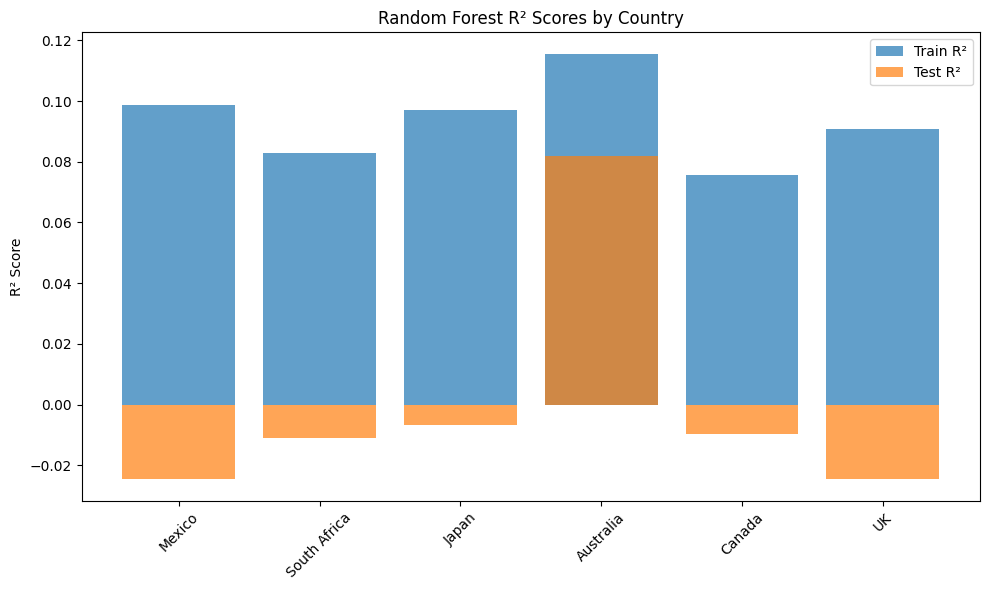

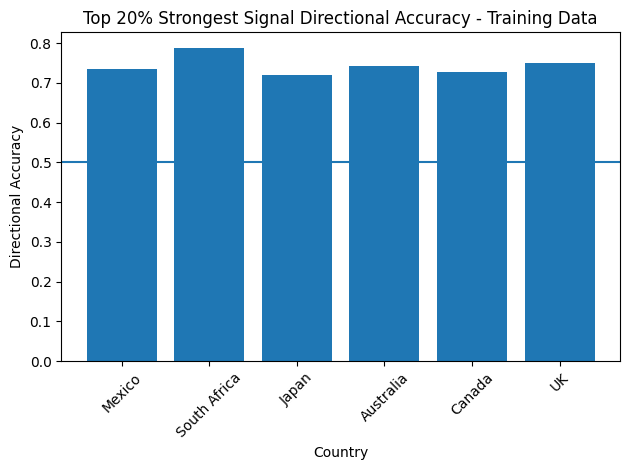

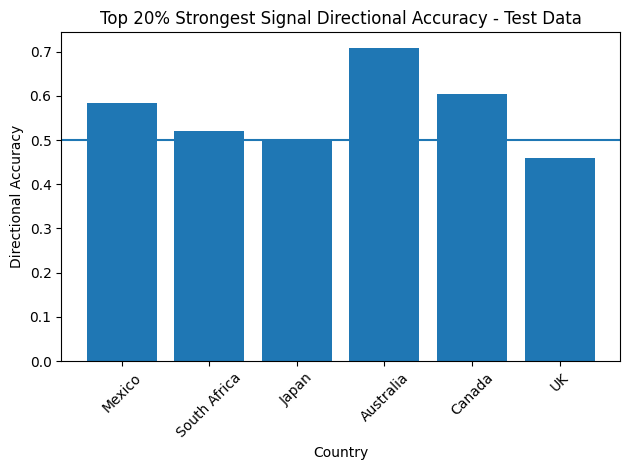

In [193]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(train_r2s.keys(), train_r2s.values(), alpha=0.7, label='Train R²')
plt.bar(test_r2s.keys(), test_r2s.values(), alpha=0.7, label='Test R²')
plt.ylabel('R² Score')
plt.title('Random Forest R² Scores by Country')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Extract countries and second value from tuple
countries2 = list(train_accuracies.keys())
values = [v[0][1] for v in train_accuracies.values()]

# Create bar plot
plt.figure()
plt.bar(countries2, values)

plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Training Data")
plt.xticks(rotation=45)

# Optional benchmark line at 0.5
plt.axhline(0.5)

plt.tight_layout()
plt.show()

# Extract countries and second value from tuple
countries2 = list(test_accuracies.keys())
values = [v[0][1] for v in test_accuracies.values()]

# Create bar plot
plt.figure()
plt.bar(countries2, values)

plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Test Data")
plt.xticks(rotation=45)

# Optional benchmark line at 0.5
plt.axhline(0.5)

plt.tight_layout()
plt.show()

# Random Forest - drop SPY

In [198]:
preds = pd.DataFrame()
train_r2s = {}
test_r2s = {}
train_accuracies = {}
test_accuracies = {}

for country, data in countries.items():
    if country not in country_residuals:
        print(f"Residuals for {country} not found. Skipping regression.")
        continue
    X_train = countries[country]['2022-01-01':'2024-09-30']
    y_train = country_residuals[country]['2022-01-01':'2024-09-30'].shift(-1).dropna()  # Shift to align with next day's return
    X_train = X_train.copy()
    y_train = y_train.copy()
    X_train.index = pd.to_datetime(X_train.index)
    y_train.index = pd.to_datetime(y_train.index)
    df_train = pd.concat([X_train, y_train], axis=1).dropna()
    df_train.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features

    X_test = countries[country]['2025-01-01':'2026-01-01']
    y_test = country_residuals[country]['2025-01-01':'2026-01-01'].shift(-1).dropna()  # Shift to align with next day's return
    X_test = X_test.copy()
    y_test = y_test.copy()
    X_test.index = pd.to_datetime(X_test.index)
    y_test.index = pd.to_datetime(y_test.index)
    df_test = pd.concat([X_test, y_test], axis=1).dropna()
    df_test.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features

    print(f"\nRandom Forest Regression Results for {country}:")
    rf_predictions, rf_model_instance ,ys, train_r2, test_r2, strong_acc_train, strong_acc_test= random_forest_model(df_train.iloc[:, :-1], df_train.iloc[:, -1], df_test.iloc[:, :-1], df_test.iloc[:, -1])
    if country == 'Mexico':
        preds.index = ys.index
    preds[country] = rf_predictions
    train_r2s[country] = train_r2
    test_r2s[country] = test_r2
    train_accuracies[country] = strong_acc_train
    test_accuracies[country] = strong_acc_test

    


Random Forest Regression Results for Mexico:

Importance-Based Feature Selection:
Training Data:
Train R² (Reduced): 0.09154003612603756
Overall Directional Accuracy: 0.5820668693009119
Top 20% Strongest Signals:
Directional Accuracy: 0.7196969696969697

Testing Data:
Reduced Test R²: -0.017060482790648424
Overall Directional Accuracy: 0.5588235294117647
Top 20% Strongest Signals:
Directional Accuracy: 0.6458333333333334
Residuals for Brazil not found. Skipping regression.

Random Forest Regression Results for South Africa:

Importance-Based Feature Selection:
Training Data:
Train R² (Reduced): 0.08027212085526714
Overall Directional Accuracy: 0.6322188449848024
Top 20% Strongest Signals:
Directional Accuracy: 0.75

Testing Data:
Reduced Test R²: -0.009404990034544314
Overall Directional Accuracy: 0.5210084033613446
Top 20% Strongest Signals:
Directional Accuracy: 0.6041666666666666

Random Forest Regression Results for Japan:

Importance-Based Feature Selection:
Training Data:
Train 

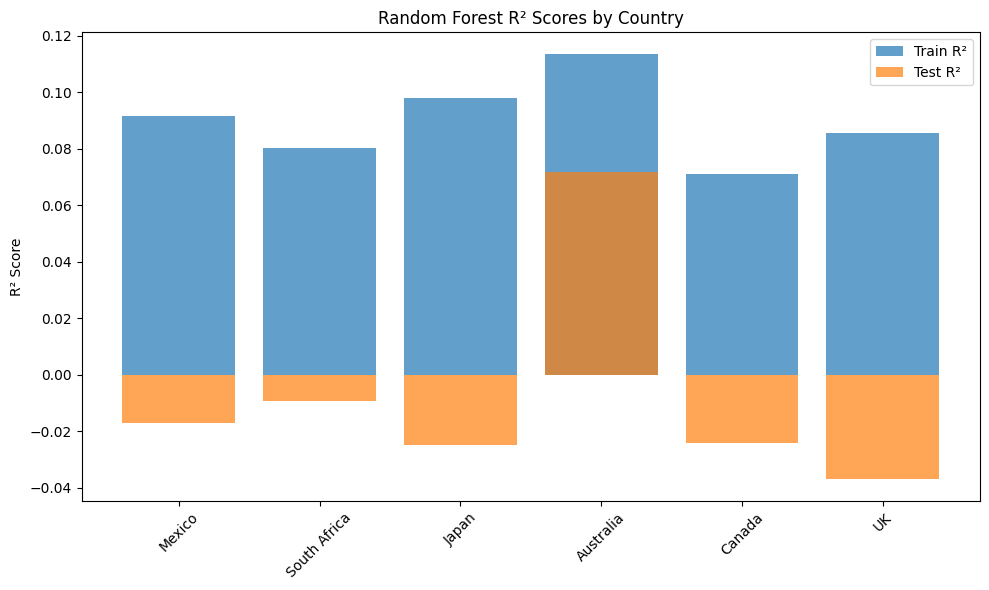

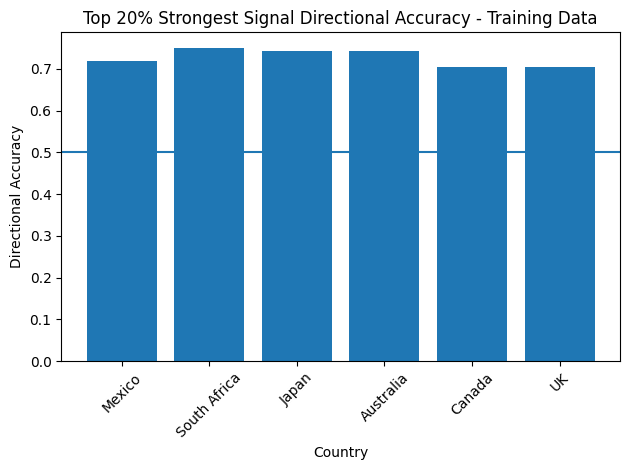

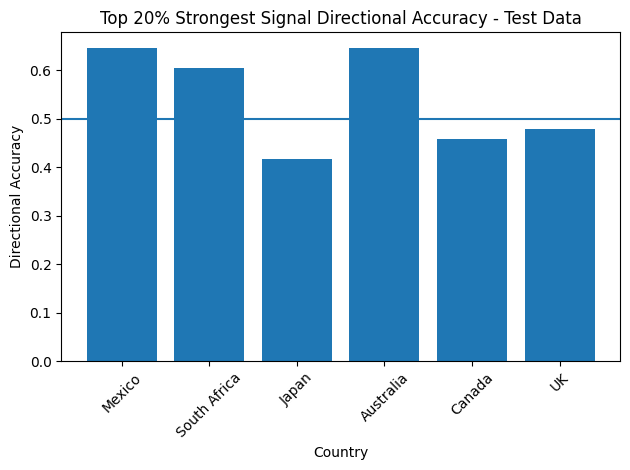

In [199]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(train_r2s.keys(), train_r2s.values(), alpha=0.7, label='Train R²')
plt.bar(test_r2s.keys(), test_r2s.values(), alpha=0.7, label='Test R²')
plt.ylabel('R² Score')
plt.title('Random Forest R² Scores by Country')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Extract countries and second value from tuple
countries2 = list(train_accuracies.keys())
values = [v[0][1] for v in train_accuracies.values()]

# Create bar plot
plt.figure()
plt.bar(countries2, values)

plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Training Data")
plt.xticks(rotation=45)

# Optional benchmark line at 0.5
plt.axhline(0.5)

plt.tight_layout()
plt.show()
# Extract countries and second value from tuple
countries2 = list(test_accuracies.keys())
values = [v[0][1] for v in test_accuracies.values()]

# Create bar plot
plt.figure()
plt.bar(countries2, values)

plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Test Data")
plt.xticks(rotation=45)

# Optional benchmark line at 0.5
plt.axhline(0.5)

plt.tight_layout()
plt.show()

In [200]:
preds.to_csv("../data/rf_predictions.csv")